Decision Tree:



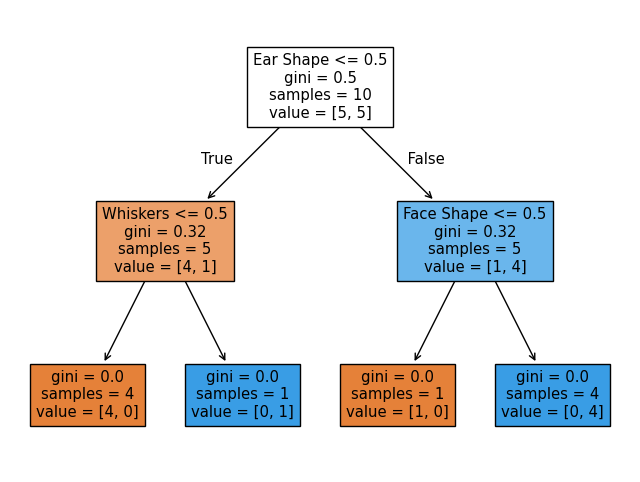


Predictions: [1 1 0 0 1 1 0 1 0 0]
Accuracy: 1.0


In [5]:
import numpy as np

# ---------------------------
# DATASET
# ---------------------------
X_train = np.array([
    [1, 1, 1],
    [0, 0, 1],
    [0, 1, 0],
    [1, 0, 1],
    [1, 1, 1],
    [1, 1, 0],
    [0, 0, 0],
    [1, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
])

y_train = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])

feature_names = ['Ear Shape', 'Face Shape', 'Whiskers']

# ---------------------------
# ENTROPY FUNCTION
# ---------------------------
def entropy(p):
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


# ---------------------------
# SPLIT FUNCTION
# ---------------------------
def split_indices(X, feature_index):
    left_indices = []
    right_indices = []

    for i, x in enumerate(X):
        if x[feature_index] == 1:
            left_indices.append(i)
        else:
            right_indices.append(i)

    return left_indices, right_indices


# ---------------------------
# WEIGHTED ENTROPY
# ---------------------------
def weighted_entropy(X, y, left_indices, right_indices):
    w_left = len(left_indices) / len(X)
    w_right = len(right_indices) / len(X)

    p_left = sum(y[left_indices]) / len(left_indices) if len(left_indices) > 0 else 0
    p_right = sum(y[right_indices]) / len(right_indices) if len(right_indices) > 0 else 0

    return w_left * entropy(p_left) + w_right * entropy(p_right)


# ---------------------------
# INFORMATION GAIN
# ---------------------------
def information_gain(X, y, left_indices, right_indices):
    p_node = sum(y) / len(y)
    h_node = entropy(p_node)

    w_entropy = weighted_entropy(X, y, left_indices, right_indices)

    return h_node - w_entropy


# ---------------------------
# BEST SPLIT
# ---------------------------
def best_split(X, y):
    best_feature = -1
    best_gain = -1
    best_left = None
    best_right = None

    n_features = X.shape[1]

    for i in range(n_features):
        left_indices, right_indices = split_indices(X, i)
        gain = information_gain(X, y, left_indices, right_indices)

        if gain > best_gain:
            best_gain = gain
            best_feature = i
            best_left = left_indices
            best_right = right_indices

    return best_feature, best_left, best_right


# ---------------------------
# TREE NODE
# ---------------------------
class Node:
    def __init__(self, feature=None, left=None, right=None, value=None):
        self.feature = feature
        self.left = left
        self.right = right
        self.value = value  # leaf value


# ---------------------------
# BUILD TREE (RECURSIVE)
# ---------------------------
def build_tree(X, y, depth=0, max_depth=2):
    num_samples = len(y)
    num_ones = sum(y)

    # stopping conditions
    if num_samples == 0:
        return None

    if num_ones == 0 or num_ones == num_samples:
        return Node(value=int(num_ones > 0))

    if depth >= max_depth:
        return Node(value=int(num_ones >= num_samples / 2))

    feature, left_idx, right_idx = best_split(X, y)

    if feature == -1:
        return Node(value=int(num_ones >= num_samples / 2))

    left_subtree = build_tree(X[left_idx], y[left_idx], depth + 1, max_depth)
    right_subtree = build_tree(X[right_idx], y[right_idx], depth + 1, max_depth)

    return Node(feature=feature, left=left_subtree, right=right_subtree)


# ---------------------------
# PREDICT
# ---------------------------
def predict_one(x, node):
    if node.value is not None:
        return node.value

    if x[node.feature] == 1:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)


def predict(X, tree):
    return np.array([predict_one(x, tree) for x in X])


# ---------------------------
# PRINT TREE (for visualization)
# ---------------------------
def print_tree(node, depth=0):
    indent = "  " * depth

    if node.value is not None:
        print(indent + f"Leaf: {node.value}")
        return

    print(indent + f"[Feature: {feature_names[node.feature]}]")

    print(indent + "-> Left (1):")
    print_tree(node.left, depth + 1)

    print(indent + "-> Right (0):")
    print_tree(node.right, depth + 1)


# ---------------------------
# RUN EVERYTHING
# ---------------------------
tree = build_tree(X_train, y_train, max_depth=2)

print("Decision Tree:\n")
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train, y_train)

plt.figure(figsize=(8,6))
plot_tree(clf, feature_names=feature_names, filled=True)
plt.show()

y_pred = predict(X_train, tree)

print("\nPredictions:", y_pred)
print("Accuracy:", np.mean(y_pred == y_train))

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# If using Jupyter
%matplotlib inline

RANDOM_STATE = 55

In [12]:
from google.colab import files
files.upload()

Saving heart.csv to heart.csv


{'heart.csv': b'Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease\n40,M,ATA,140,289,0,Normal,172,N,0,Up,0\n49,F,NAP,160,180,0,Normal,156,N,1,Flat,1\n37,M,ATA,130,283,0,ST,98,N,0,Up,0\n48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1\n54,M,NAP,150,195,0,Normal,122,N,0,Up,0\n39,M,NAP,120,339,0,Normal,170,N,0,Up,0\n45,F,ATA,130,237,0,Normal,170,N,0,Up,0\n54,M,ATA,110,208,0,Normal,142,N,0,Up,0\n37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1\n48,F,ATA,120,284,0,Normal,120,N,0,Up,0\n37,F,NAP,130,211,0,Normal,142,N,0,Up,0\n58,M,ATA,136,164,0,ST,99,Y,2,Flat,1\n39,M,ATA,120,204,0,Normal,145,N,0,Up,0\n49,M,ASY,140,234,0,Normal,140,Y,1,Flat,1\n42,F,NAP,115,211,0,ST,137,N,0,Up,0\n54,F,ATA,120,273,0,Normal,150,N,1.5,Flat,0\n38,M,ASY,110,196,0,Normal,166,N,0,Flat,1\n43,F,ATA,120,201,0,Normal,165,N,0,Up,0\n60,M,ASY,100,248,0,Normal,125,N,1,Flat,1\n36,M,ATA,120,267,0,Normal,160,N,3,Flat,1\n43,F,TA,100,223,0,Normal,142,N,0,Up,0\n44,M,ATA,120,184,0

In [14]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [15]:
cat_variables = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

df = pd.get_dummies(df, columns=cat_variables)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [16]:
features = [x for x in df.columns if x != 'HeartDisease']

X = df[features]
y = df['HeartDisease']

print("Number of features:", len(features))

Number of features: 20


In [17]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 55

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    train_size=0.8,
    random_state=RANDOM_STATE,
    shuffle=True
)

print(f"train samples: {len(X_train)}")
print(f"validation samples: {len(X_val)}")
print(f"target proportion: {sum(y_train)/len(y_train):.4f}")

train samples: 734
validation samples: 184
target proportion: 0.5518


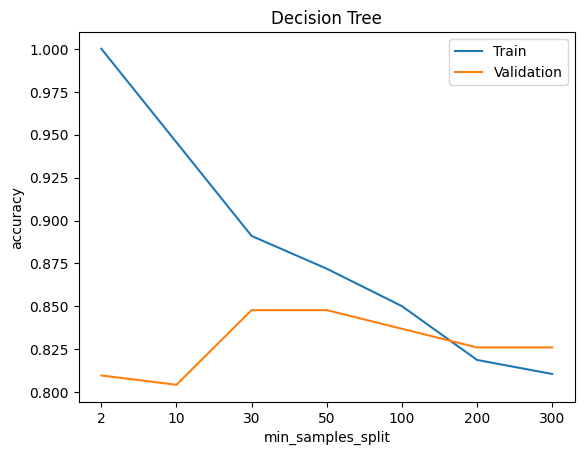

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

min_samples_split_list = [2, 10, 30, 50, 100, 200, 300]

train_acc = []
val_acc = []

for m in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split=m, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    val_acc.append(accuracy_score(y_val, model.predict(X_val)))

plt.plot(train_acc, label='Train')
plt.plot(val_acc, label='Validation')
plt.xticks(range(len(min_samples_split_list)), min_samples_split_list)
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.title('Decision Tree')
plt.legend()
plt.show()

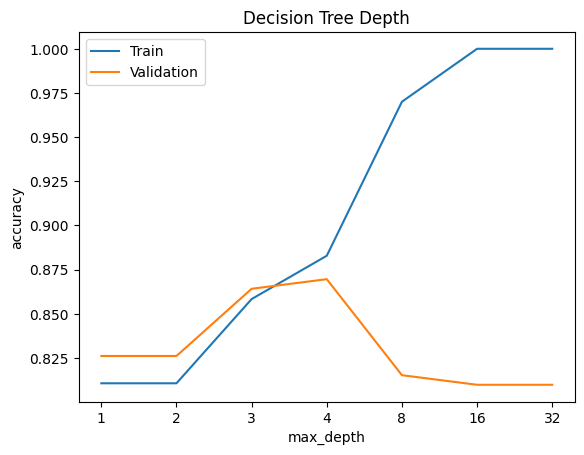

In [19]:
max_depth_list = [1, 2, 3, 4, 8, 16, 32]

train_acc = []
val_acc = []

for d in max_depth_list:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    val_acc.append(accuracy_score(y_val, model.predict(X_val)))

plt.plot(train_acc, label='Train')
plt.plot(val_acc, label='Validation')
plt.xticks(range(len(max_depth_list)), max_depth_list)
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('Decision Tree Depth')
plt.legend()
plt.show()

In [20]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    random_state=RANDOM_STATE
)

decision_tree_model.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, decision_tree_model.predict(X_train)))
print("Validation accuracy:", accuracy_score(y_val, decision_tree_model.predict(X_val)))

Train accuracy: 0.8583106267029973
Validation accuracy: 0.8641304347826086


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


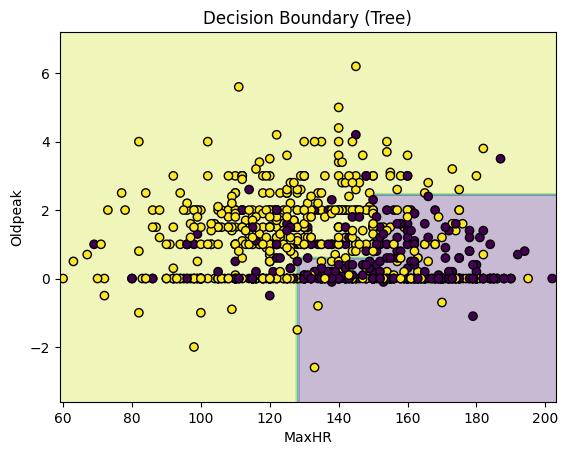

In [21]:
features_2d = ['MaxHR', 'Oldpeak']

X_2d = X[features_2d]

X_train_2d, X_val_2d, y_train_2d, y_val_2d = train_test_split(
    X_2d, y, train_size=0.8, random_state=RANDOM_STATE
)

model_2d = DecisionTreeClassifier(max_depth=3)
model_2d.fit(X_train_2d, y_train_2d)

# meshgrid
x_min, x_max = X_2d.iloc[:,0].min()-1, X_2d.iloc[:,0].max()+1
y_min, y_max = X_2d.iloc[:,1].min()-1, X_2d.iloc[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_2d.iloc[:,0], X_2d.iloc[:,1], c=y, edgecolor='k')
plt.xlabel('MaxHR')
plt.ylabel('Oldpeak')
plt.title("Decision Boundary (Tree)")
plt.show()

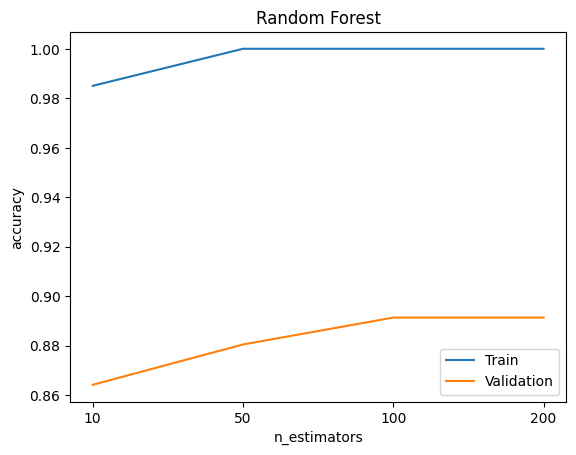

In [22]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [10, 50, 100, 200]

train_acc = []
val_acc = []

for n in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    val_acc.append(accuracy_score(y_val, model.predict(X_val)))

plt.plot(train_acc, label='Train')
plt.plot(val_acc, label='Validation')
plt.xticks(range(len(n_estimators_list)), n_estimators_list)
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.title('Random Forest')
plt.legend()
plt.show()

In [23]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=16,
    min_samples_split=10,
    random_state=RANDOM_STATE
)

random_forest_model.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, random_forest_model.predict(X_train)))
print("Validation accuracy:", accuracy_score(y_val, random_forest_model.predict(X_val)))

Train accuracy: 0.9305177111716622
Validation accuracy: 0.8913043478260869


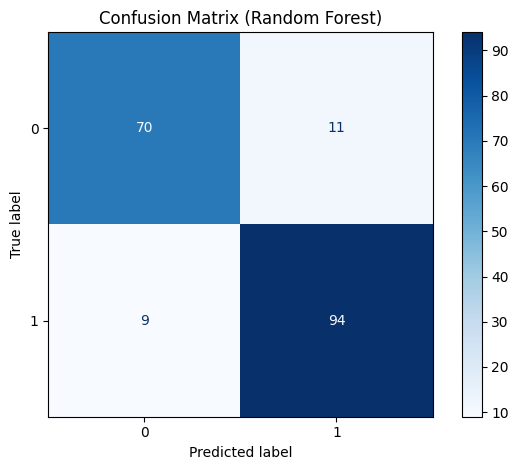

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    random_forest_model,
    X_val,
    y_val,
    cmap="Blues"
)

plt.title("Confusion Matrix (Random Forest)")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=300)
plt.show()

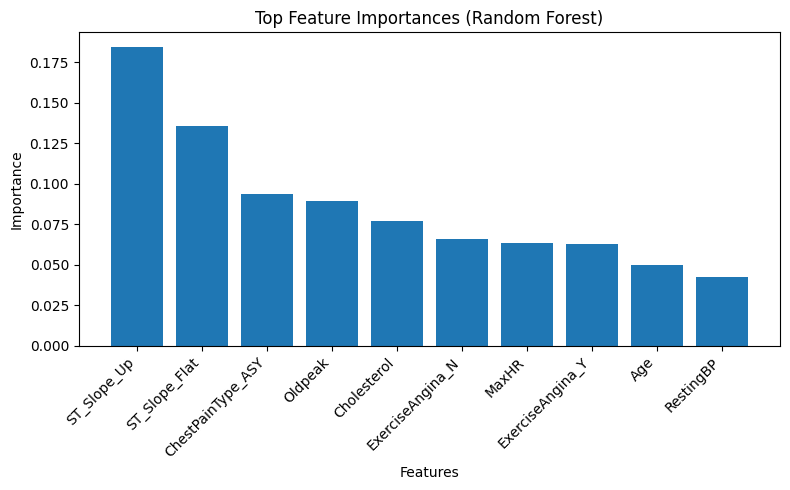

In [27]:
importances = random_forest_model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 10

plt.figure(figsize=(8,5))
plt.bar(range(top_n), importances[indices][:top_n])

plt.xticks(
    range(top_n),
    [X.columns[i] for i in indices[:top_n]],
    rotation=45,
    ha='right'
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top Feature Importances (Random Forest)")

plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=300)
plt.show()